In [7]:
# notebooks/01_eda.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

# -----------------------------
# Paths
# -----------------------------

DATA_PATH = Path("../data/processed/network_logs_preprocessed.csv")
FIGURES_PATH = Path("../reports/figures")

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load dataset
# -----------------------------

print("Loading dataset...")

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)

# Optional sampling for faster EDA (recommended for very large datasets)
if len(df) > 300000:
    df = df.sample(300000, random_state=42)
    print("Sampled shape:", df.shape)

df = df.copy()

print(df.head())

# -----------------------------
# Create synthetic timestamp
# -----------------------------

df["timestamp"] = pd.date_range(
    start="2024-01-01",
    periods=len(df),
    freq="s"
)



Loading dataset...
Original shape: (1980433, 145)
Sampled shape: (300000, 145)
              srcip          dstip     sport    dsport       dur    sbytes  \
1019052  59.166.0.4  149.171.126.9 -1.012861 -0.707832  0.058926 -0.056206   
1962860  59.166.0.0  149.171.126.0 -0.938293 -0.055005 -0.052823 -0.029071   
1902930  59.166.0.8  149.171.126.4 -1.402794  2.456339 -0.034729 -0.076246   
3592     59.166.0.0  149.171.126.7 -1.233208  1.449251 -0.051195 -0.000697   
522491   59.166.0.4  149.171.126.6 -1.306622 -0.447212  0.074760 -0.021787   

           dbytes      sttl      dttl  label  ...  proto_visa  proto_vmtp  \
1019052 -0.191019 -0.213027 -0.194812      0  ...       False       False   
1962860  0.012270 -0.213027 -0.194812      0  ...       False       False   
1902930 -0.198884 -0.213027 -0.194812      0  ...       False       False   
3592     0.239951 -0.213027 -0.194812      0  ...       False       False   
522491  -0.138842 -0.213027 -0.194812      0  ...       False      

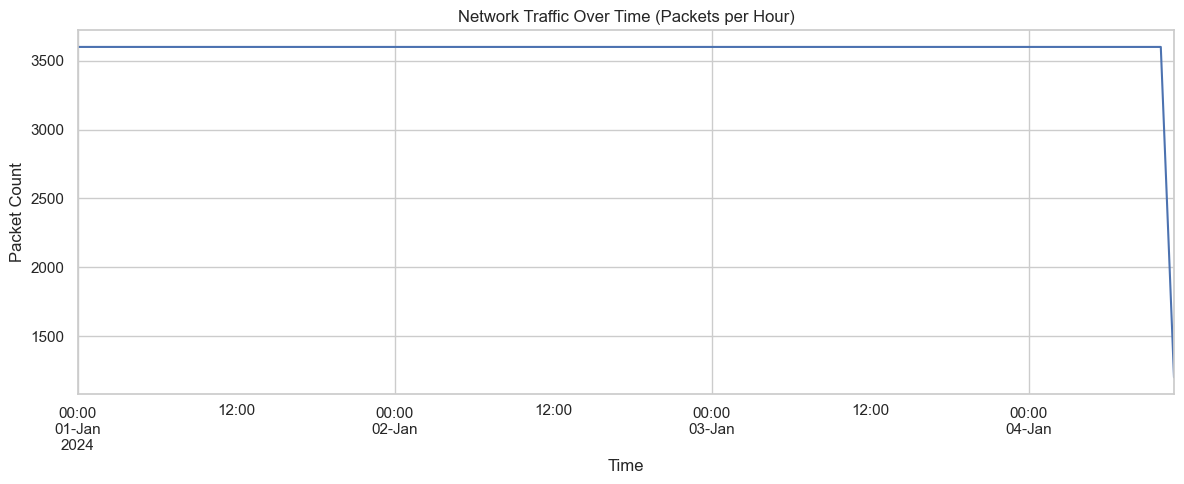

In [8]:
# -----------------------------
# 1. Traffic Volume Over Time
# -----------------------------

traffic_per_hour = df.resample("h", on="timestamp").size()

plt.figure(figsize=(12,5))
traffic_per_hour.plot()

plt.title("Network Traffic Over Time (Packets per Hour)")
plt.xlabel("Time")
plt.ylabel("Packet Count")

plt.tight_layout()

plt.savefig(FIGURES_PATH / "traffic_over_time.png")

plt.show()


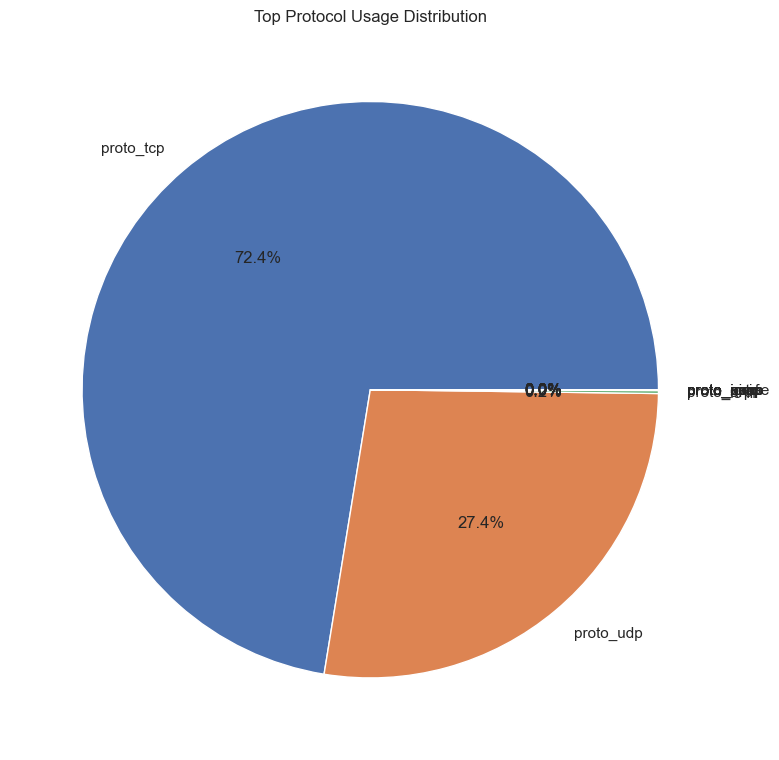

In [9]:
# 2. Protocol Distribution
# -----------------------------

protocol_cols = [col for col in df.columns if col.startswith("proto_")]

protocol_counts = df[protocol_cols].sum().sort_values(ascending=False)

# Keep only top 10 protocols for visualization
top_protocols = protocol_counts.head(10)

plt.figure(figsize=(8,8))

top_protocols.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Top Protocol Usage Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig(FIGURES_PATH / "protocol_usage.png")

plt.show()

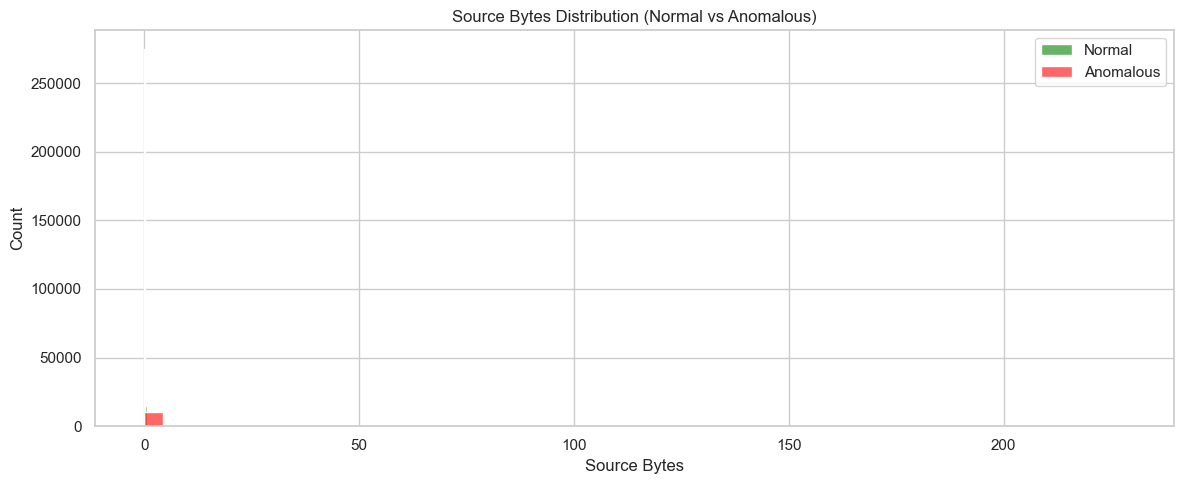

In [10]:
# -----------------------------
# 3. Packet Size Distribution
# -----------------------------

plt.figure(figsize=(12,5))

sns.histplot(
    df[df["label"] == 0]["sbytes"],
    bins=50,
    color="green",
    label="Normal",
    alpha=0.6
)

sns.histplot(
    df[df["label"] == 1]["sbytes"],
    bins=50,
    color="red",
    label="Anomalous",
    alpha=0.6
)

plt.title("Source Bytes Distribution (Normal vs Anomalous)")
plt.xlabel("Source Bytes")
plt.ylabel("Count")

plt.legend()

plt.tight_layout()

plt.savefig(FIGURES_PATH / "packet_size_hist.png")

plt.show()


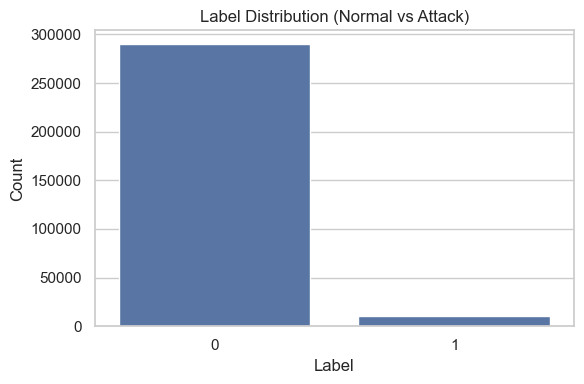

In [11]:
# 4. Label Distribution
# -----------------------------

plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Label Distribution (Normal vs Attack)")
plt.xlabel("Label")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(FIGURES_PATH / "label_distribution.png")

plt.show()


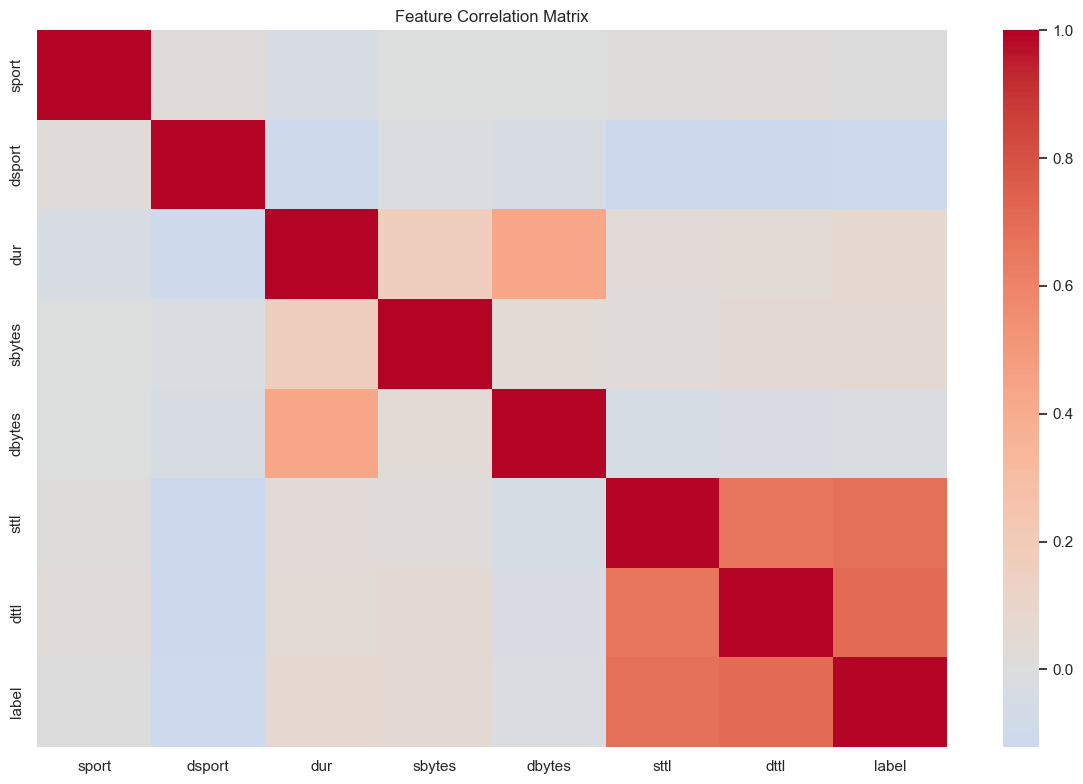

EDA completed. Figures saved to: ..\reports\figures


In [12]:
# -----------------------------
# 5. Feature Correlation (Top Numeric)
# -----------------------------

numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    cbar=True
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(FIGURES_PATH / "correlation_matrix.png")

plt.show()

print("EDA completed. Figures saved to:", FIGURES_PATH)